<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="Skills Network Logo">
    </a>
</p>


# Portfolio Project: Model Evaluation and Refinement — Medical Insurance Cost Prediction
**IBM Data Science Professional Certificate | Module 5: Model Evaluation and Refinement**

### 👨‍💻 Executive Summary
This project aims to predict individual medical costs billed by health insurance based on demographic and lifestyle factors. Using the Medical Insurance Price Prediction dataset (from Kaggle/IBM), I developed and refined a series of machine learning models to identify the primary drivers of healthcare expenses.

Key Achievements:

* **Feature Engineering:** Implemented 2nd-degree polynomial transformations to capture non-linear relationships (e.g., the synergistic effect of smoking and high BMI).

* **Model Refinement:** Built a robust training pipeline integrating `StandardScaler` and `PolynomialFeatures`.

* **Regularization:** Applied Ridge Regression (L2 Regularization) to mitigate overfitting, ensuring the model generalizes well to unseen data.

* **Performance:** Improved the model's predictive power from a baseline $R^2$ of 0.62 to a refined **0.841**.

---
*Original lab framework provided by IBM Skills Network. Technical implementation, 
statistical analysis, and model interpretation performed by [Roberto Castro/rcastro-ai](https://github.com/rcastro-ai)*

# **Practice Project: Insurance Cost Analysis**

Estimated time needed: **75** minutes

In this project, you have to perform analytics operations on an insurance database that uses the below mentioned parameters.

| Parameter |Description| Content type |
|---|----|---|
|age| Age in years| integer |
|gender| Male or Female|integer (1 or 2)|
| bmi | Body mass index | float |
|no_of_children| Number of children | integer|
|smoker| Whether smoker or not | integer (0 or 1)|
|region| Which US region - NW, NE, SW, SE | integer (1,2,3 or 4 respectively)| 
|charges| Annual Insurance charges in USD | float|

## Objectives 
In this project, you will:
 - Load the data as a `pandas` dataframe
 - Clean the data, taking care of the blank entries
 - Run exploratory data analysis (EDA) and identify the attributes that most affect the `charges`
 - Develop single variable and multi variable Linear Regression models for predicting the `charges`
 - Use Ridge regression to refine the performance of Linear regression models. 
 


# Setup


For this lab, we will be using the following libraries:
* `skillsnetwork` to download the data
*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for managing the data.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations.
*   [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for machine learning and machine-learning-pipeline related functions.
*   [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for visualizing the data.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools.


The following required libraries are __not__ pre-installed in the Skills Network Labs environment. __You will need to run the following cell__ to install them:


In [1]:
# When running in the browser use the below code

#import piplite
#await piplite.install('seaborn')

### Importing Required Libraries

_We recommend you import all required libraries in one place (here):_


In [2]:
# Importing all needed libraries here

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

<details>
    <summary>Click here for Solution</summary>

```python
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split
```

</details>


### Download the dataset to this lab environment

Run the cell below to load the dataset to this lab environment.


In [3]:
# Use this code if running in the browser

#from pyodide.http import pyfetch

#async def download(url, filename):
#    response = await pyfetch(url)
#    if response.status == 200:
#        with open(filename, "wb") as f:
#            f.write(await response.bytes())

In [4]:
# Storing values for file path and file name

filepath = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/medical_insurance_dataset.csv'
filename = "insurance.csv"

In [5]:
# Use this code if running in the browser

#await download(filepath, filename)

> Note: This version of the lab is working on JupyterLite, which requires the dataset to be downloaded to the interface.While working on the downloaded version of this notebook on their local machines(Jupyter Anaconda), the learners can simply **skip the steps above,** and simply use the URL directly in the `pandas.read_csv()` function. You can uncomment and run the statements in the cell below.


In [6]:
# Reading dataset into dataframe

df = pd.read_csv(filepath, header=None) # The file has no headers

In [7]:
# Saving the original file locally 

#df.to_csv(filename)

In [8]:
# Use this code if running in the browser

#df = pd.read_csv(filename)

# Task 1 : Import the dataset

Import the dataset into a `pandas` dataframe. Note that there are currently no headers in the CSV file. 

Print the first 10 rows of the dataframe to confirm successful loading.


In [9]:
# Showing the first 10 rows of the dataframe. The data was already loaded in the previous section

df.head(10)

,0,1,2,3,4,5,6
0,19,1,27.900,0,1,3,16884.92400
1,18,2,33.770,1,0,4,1725.55230
2,28,2,33.000,3,0,4,4449.46200
3,33,2,22.705,0,0,1,21984.47061
4,32,2,28.880,0,0,1,3866.85520
5,31,1,25.740,0,?,4,3756.62160
6,46,1,33.440,1,0,4,8240.58960
7,37,1,27.740,3,0,1,7281.50560
8,37,2,29.830,2,0,2,6406.41070
9,60,1,25.840,0,0,1,28923.13692


<details>
    <summary>Click here for Solution</summary>

```python
df = pd.read_csv(file_name, header=None)
print(df.head(10))
```

</details>


Add the headers to the dataframe, as mentioned in the project scenario. 


In [10]:
# Assigning headers to the dataframe

headers = ['age', 'gender', 'bmi', 'no_of_children', 'smoker', 'region', 'charges']
df.columns = headers

<details>
    <summary>Click here for Solution</summary>

```python
headers = ["age", "gender", "bmi", "no_of_children", "smoker", "region", "charges"]
df.columns = headers
```

</details>


Now, replace the '?' entries with 'NaN' values.


In [11]:
# Replacing all empty values represented by '?' with NaN

df = df.replace("?", np.nan)

<details>
    <summary>Click here for Solution</summary>

```python
df.replace('?', np.nan, inplace = True)
```

</details>


# Task 2 : Data Wrangling


Use `dataframe.info()` to identify the columns that have some 'Null' (or NaN) information.


In [12]:
# Checking which columns have Null or NaN values

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2768 non-null   object 
 1   gender          2772 non-null   int64  
 2   bmi             2772 non-null   float64
 3   no_of_children  2772 non-null   int64  
 4   smoker          2765 non-null   object 
 5   region          2772 non-null   int64  
 6   charges         2772 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 151.7+ KB
None


In [13]:
# Obtain missing data

missing_data = df.isnull()
missing_data.head(10)

,age,gender,bmi,no_of_children,smoker,region,charges
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
5,False,False,False,False,True,False,False
6,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False


In [14]:
# Getting the list of columns and the number of missing values 

df.isnull().sum()

age               4
gender            0
bmi               0
no_of_children    0
smoker            7
region            0
charges           0
dtype: int64

<details>
    <summary>Click here for Solution</summary>

```python
print(df.info())
```

</details>


Handle missing data:

- For continuous attributes (e.g., age), replace missing values with the mean.
- For categorical attributes (e.g., smoker), replace missing values with the most frequent value.
- Update the data types of the respective columns.
- Verify the update using `df.info()`.


In [15]:
# Handling the missing data

# Converting data type of column 'age' to int first
df["age"] = df["age"].astype("Int64")

# Calculating the mean value for 'age'
avg_age = df["age"].mean(axis=0).round()

# Replacing 'age' containing NaN values with the mean value as this is a continuous variable
df["age"] = df["age"].replace(np.nan, avg_age)

# Converting data type of column 'smoker' to int first
df["smoker"] = df["smoker"].astype("Int64")

# Obtaining the most frequest value for 'smoker' as this is a categorical attribute
most_freq_smoker_value =  df['smoker'].value_counts().idxmax()

# Replacing 'smoker' containing NaN values with the most frequent value
df["smoker"] = df["smoker"].replace(np.nan, most_freq_smoker_value)


In [16]:
# Getting the list of columns and the number of missing values after fixing the missing data 

df.isnull().sum()

age               0
gender            0
bmi               0
no_of_children    0
smoker            0
region            0
charges           0
dtype: int64

In [17]:
# Showing column types after fixing the data

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2772 non-null   Int64  
 1   gender          2772 non-null   int64  
 2   bmi             2772 non-null   float64
 3   no_of_children  2772 non-null   int64  
 4   smoker          2772 non-null   Int64  
 5   region          2772 non-null   int64  
 6   charges         2772 non-null   float64
dtypes: Int64(2), float64(2), int64(3)
memory usage: 157.1 KB
None


In [18]:
# Now that all NaNs have been cleared, converting back to standard int64

df["age"] = df["age"].astype("int")
df["smoker"] = df["smoker"].astype("int")

In [19]:
# Showing column types after converting to the right int64 data type ('age' and 'smoker' columns)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2772 non-null   int64  
 1   gender          2772 non-null   int64  
 2   bmi             2772 non-null   float64
 3   no_of_children  2772 non-null   int64  
 4   smoker          2772 non-null   int64  
 5   region          2772 non-null   int64  
 6   charges         2772 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 151.7 KB
None


<details>
    <summary>Click here for Solution</summary>

```python
# smoker is a categorical attribute, replace with most frequent entry
is_smoker = df['smoker'].value_counts().idxmax()
df["smoker"].replace(np.nan, is_smoker, inplace=True)

# age is a continuous variable, replace with mean age
mean_age = df['age'].astype('float').mean(axis=0)
df["age"].replace(np.nan, mean_age, inplace=True)

# Update data types
df[["age","smoker"]] = df[["age","smoker"]].astype("int")

print(df.info())
```

</details>


Also note, that the `charges` column has values which are more than 2 decimal places long. Update the `charges` column such that all values are rounded to nearest 2 decimal places. Verify conversion by printing the first 5 values of the updated dataframe.


In [20]:
# Rounding the values of the column 'charges' so they have only 2 decimal posittions

df["charges"] = df["charges"].round(2)

In [21]:
# Shoing the first 5 rows of the dataframe

df.head()

,age,gender,bmi,no_of_children,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92
1,18,2,33.770,1,0,4,1725.55
2,28,2,33.000,3,0,4,4449.46
3,33,2,22.705,0,0,1,21984.47
4,32,2,28.880,0,0,1,3866.86


<details>
    <summary>Click here for Solution</summary>

```python
df[["charges"]] = np.round(df[["charges"]],2)
print(df.head())
```
</details>


# Task 3 : Exploratory Data Analysis (EDA)

Implement the regression plot for `charges` with respect to `bmi`. 

The Pearson correlation coefficient is 0.19984605168370884  with a p-value of =  2.29351916547895e-26


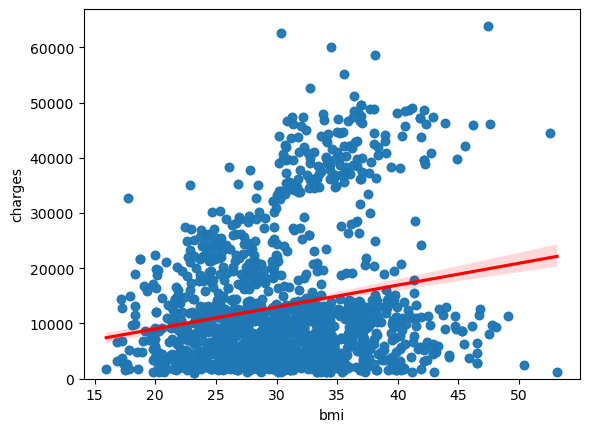

In [22]:
# Implementing the regression plot for 'bmi' against 'charges'

# Creating a scatterplot for 'bmi' and 'charges' to see bmi as a potential predictor of variable charges
sns.regplot(x="bmi", y="charges", data=df, line_kws={"color": "red"})
plt.ylim(0,)

# Get correlation information
pearson_coef, p_value = stats.pearsonr(df['bmi'], df['charges'])
print( "The Pearson correlation coefficient is", pearson_coef, " with a p-value of = ", p_value ) 


**Analysis of results**

The p-value ($< 0.05$) indicates that the relationship is statistically significant, meaning it is very unlikely to be due to random chance. However, the Pearson correlation coefficient of $0.1998$ indicates a weak positive linear relationship. In practical terms, while BMI does influence insurance charges, it only explains a small portion of the total variance on its own.

<details>
    <summary>Click here for Solution</summary>

```python
sns.regplot(x="bmi", y="charges", data=df, line_kws={"color": "red"})
plt.ylim(0,)
```
</details>


Implement the box plot for `charges` with respect to `smoker`.


The Pearson correlation coefficient is 0.788783350098377  with a p-value of =  0.0


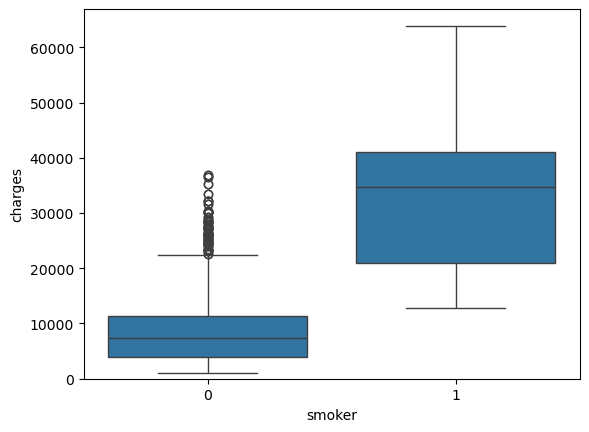

In [23]:
# Implementing the regression plot for 'smoker' against 'charges'

# Creating a boxplot for 'smoker' and 'charges' to see smoker as a potential predictor of variable charges
sns.boxplot(x="smoker", y="charges", data=df)
plt.ylim(0,)

# Get correlation information
pearson_coef, p_value = stats.pearsonr(df['smoker'], df['charges'])
print( "The Pearson correlation coefficient is", pearson_coef, " with a p-value of = ", p_value ) 


**Analysis of results**

The p-value ($< 0.001$) confirms that the relationship is **statistically significant**, with virtually zero probability that this variance is due to chance. The Pearson correlation coefficient of $0.788$ indicates a **strong positive relationship**. 

**Key Insight**

The boxplot visually demonstrates a strong "premium gap", where the median charges for smokers are roughly quadruple those of non-smokers. This suggests that "smoker" will likely be an influential feature in our predictive model.

<details>
    <summary>Click here for Solution</summary>

```python
sns.boxplot(x="smoker", y="charges", data=df)
```
</details>


Print the correlation matrix for the dataset.


In [24]:
# Generating the correlation matrix for dataframe df

correlation_matrix = df.corr()
correlation_matrix

,age,gender,bmi,no_of_children,smoker,region,charges
age,1.000000,-0.026046,0.113048,0.037574,-0.023286,-0.007167,0.298624
gender,-0.026046,1.000000,0.042924,0.016020,0.082326,0.022213,0.062837
bmi,0.113048,0.042924,1.000000,-0.001492,0.011489,0.271119,0.199846
no_of_children,0.037574,0.016020,-0.001492,1.000000,0.006362,-0.025717,0.066442
smoker,-0.023286,0.082326,0.011489,0.006362,1.000000,0.054077,0.788783
region,-0.007167,0.022213,0.271119,-0.025717,0.054077,1.000000,0.054058
charges,0.298624,0.062837,0.199846,0.066442,0.788783,0.054058,1.000000


**Analysis of results**

The correlation matrix confirms that **'smoker'** is the strongest predictor of insurance charges, with a high positive correlation of **0.788**. This suggests a significant linear relationship, making it the primary feature for our predictive modeling.

<details>
    <summary>Click here for Solution</summary>

```python
print(df.corr())
```
</details>


# Task 4 : Model Development

Fit a linear regression model that may be used to predict the `charges` value, just by using the `smoker` attribute of the dataset. Print the $ R^2 $ score of this model.


In [25]:
# Building a SLR model using feature 'smoker'

# Creating data sets for easy reference
x = df[['smoker']]
y = df[['charges']]

# Creating linear regression object
lr = LinearRegression()

# Fitting the model using the feature 'smoker'
lr.fit(x, y)

# Getting R-squared of this model
r_squared = lr.score(x, y)

# Printing R-squared value
print('R-squared is: ', r_squared)

R-squared is:  0.6221791733924185


**Analysis of results**

Using a simple linear regression with 'smoker' as the sole feature yields a **coefficient of determination** (R-squared) of **0.622**. This indicates that approximately **62%** of the **variation** in insurance charges can be explained by smoking status alone. While this shows 'smoker' is a strong predictor, the remaining 38% of variance suggests that other factors are required to improve the model's accuracy.

<details>
    <summary>Click here for Solution</summary>

```python
X = df[['smoker']]
Y = df['charges']
lm = LinearRegression()
lm.fit(X,Y)
print(lm.score(X, Y))
```
</details>


Fit a linear regression model that may be used to predict the `charges` value, just by using all other attributes of the dataset. Print the $ R^2 $ score of this model. You should see an improvement in the performance.


In [26]:
# Creating a linear regression object and fit the model the all features ('age', 'gender', 'bmi', 'no_of_children', 'smoker', and 'region')

# Creating datasets
x_1 = df[['age', 'gender', 'bmi', 'no_of_children', 'smoker', 'region']]
y_1 = df[['charges']]

lr_1 = LinearRegression()
lr_1.fit(x_1, y_1)

# Getting R-squared of this model
r_squared_1 = lr_1.score(x_1, y_1)

# Printing R-squared value
print('R-squared is: ', r_squared_1)

R-squared is:  0.7504083820289634


**Analysis of results**

By expanding the model to include all available features, the **coefficient of determination** (R-dquared) increases to **0.75**. This confirms that the additional variables contribute significant predictive power, accounting for an additional **13% of the variance** in insurance costs compared to the single-feature model. Now, 75% of the total variation can be explained by the combined influence of all six features.

<details>
    <summary>Click here for Solution</summary>

```python
# definition of Y and lm remain same as used in last cell. 
Z = df[["age", "gender", "bmi", "no_of_children", "smoker", "region"]]
lm.fit(Z,Y)
print(lm.score(Z, Y))
```
</details>


Create a training pipeline that uses `StandardScaler()`, `PolynomialFeatures()` and `LinearRegression()` to create a model that can predict the `charges` value using all the other attributes of the dataset. There should be even further improvement in the performance.


In [27]:
# Creating a training pipeline with a polynomial of the 2nd order and using all the six predictor variables

# Creating the data sets
x_2 = df[['age', 'gender', 'bmi', 'no_of_children', 'smoker', 'region']]
y_2 = df[['charges']]

# Splitting the data using 30% for testing
x_train_2, x_test_2, y_train_2, y_test_2 = train_test_split(x_2, y_2, test_size=0.3, random_state=0)

# Creating the tuples for the pipeline
Input=[('scale', StandardScaler()), ('polynomial', PolynomialFeatures(degree=2, include_bias=False)), ('model',LinearRegression())]

# Creating the pipeline
pipe = Pipeline(Input)

# Fitting the model - Using set of multiple features
Z = x_train_2.astype(float)
pipe.fit(Z, y_train_2)

# Generating predicted values
Ypipe = pipe.predict(x_test_2)

# Calculating R-square 
r2 = r2_score(y_test_2, Ypipe)

# Calculating MSE 
mse_p = mean_squared_error(y_test_2, Ypipe)

# Printing values
print(f'For model created with the pipeline MSE is: {mse_p} and R-squared is {r2}')  


For model created with the pipeline MSE is: 21394202.71034393 and R-squared is 0.8622658881112


**Analysis of results**

By implementing a **Training Pipeline** with `StandardScaler` and `PolynomialFeatures (degree=2)`, the model's performance improved significantly to an $R^2$ of **0.862**.This indicates that **86.2%** of the variance in insurance charges is captured by the model. The jump from the linear model's 0.75 to 0.86 proves that the relationship between features like BMI, age, and smoking is non-linear and interactive. The model is now highly effective at predicting charges for new, unseen data.

While the lab suggests fitting on the full dataset, I implemented a train/test split to validate that the model generalizes well to unseen data. An $R^2$ of 0.86 on the test set confirms the model is highly robust.


<details>
    <summary>Click here for Solution</summary>

```python
# Y and Z use the same values as defined in previous cells 
Input=[('scale',StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), ('model', LinearRegression())]
pipe=Pipeline(Input)
Z = Z.astype(float)
pipe.fit(Z,Y)
ypipe=pipe.predict(Z)
print(r2_score(Y,ypipe))
```
</details>


# Task 5 : Model Refinement

Split the data into training and testing subsets, assuming that 20% of the data will be reserved for testing.


In [28]:
# Creating the data sets
x_3 = df[['age', 'gender', 'bmi', 'no_of_children', 'smoker', 'region']]
y_3 = df[['charges']]

# Splitting the data using 20% for testing
x_train_3, x_test_3, y_train_3, y_test_3 = train_test_split(x_3, y_3, test_size=0.2, random_state=0)


<details>
    <summary>Click here for Solution</summary>

```python
# Z and Y hold same values as in previous cells
x_train, x_test, y_train, y_test = train_test_split(Z, Y, test_size=0.2, random_state=1)
```
</details>


Initialize a Ridge regressor that used hyperparameter $ \alpha = 0.1 $. Fit the model using training data data subset. Print the $ R^2 $ score for the testing data.


In [29]:
# Performing a degree two polynomial transformation

# Creating polynomial of 2nd order
pr_3 = PolynomialFeatures(degree=2)

x_train_pr_3 = pr_3.fit_transform(x_train_3)
#x_test_pr_3 = pr_3.fit_transform(x_test_3) # Not using fit_transform to avoid data leakage
x_test_pr_3 = pr_3.transform(x_test_3)

# Creating a Ridge regression with alpha (regularization parameter) set to 0.1
RM_3 = Ridge(alpha=0.1)

# Fitting the model
RM_3.fit(x_train_pr_3, y_train_3)

# Generating a prediction using the test data
yhat_3 = RM_3.predict(x_test_pr_3)

# Obtaining the score
r_squared_3 = RM_3.score(x_test_pr_3, y_test_3)

# Printing the R-squared for the model
print('R-squared for the model is: ', r_squared_3)


R-squared for the model is:  0.8410037679926488


**Analysis of results**

Implementing **Ridge Regression (alpha=0.1)** on the 2nd-degree polynomial features resulted in an $R^2$ of **0.841**. While this is a slight decrease from the standard polynomial model, it represents a more generalized and robust predictor. The Ridge penalty shrinks the coefficients of less important interaction terms, preventing the model from **overfitting** to noise in the training data. With over 84% of the variance explained, this model strikes the ideal balance between complexity and predictive stability for future insurance claims.

<details>
    <summary>Click here for Solution</summary>

```python
# x_train, x_test, y_train, y_test hold same values as in previous cells
RidgeModel=Ridge(alpha=0.1)
RidgeModel.fit(x_train, y_train)
yhat = RidgeModel.predict(x_test)
print(r2_score(y_test,yhat))
```
</details>


Apply polynomial transformation to the training parameters with degree=2. Use this transformed feature set to fit the same regression model, as above, using the training subset. Print the $ R^2 $ score for the testing subset.


**Note:** I performed this already in the previous step assuming I had to use polynomial features of degree 2. Adding a final analysis of results section below as the summary of this lab.

**Analysis of results**

| Model Type | Features Used | $R^2$ Score | Key Takeaway |
| ---------- | ------------- | ----------- | ------------ |
| **Simple Linear** | Smoker only | 0.622 | Smoking is the primary driver of cost |
| **Multiple Linear** | All 6 features | 0.750 | Age and BMI add significant value |
| **Polynomial (Deg 2)** | All 6 + interactions | 0.862 | Relationships are non-linear/interactive |
| **Ridge (Alpha 0.1)** | All 6 + interactions | **0.841** | **Best model:** Balanced and robust |

<details>
    <summary>Click here for Solution</summary>

```python
# x_train, x_test, y_train, y_test hold same values as in previous cells
pr = PolynomialFeatures(degree=2)
x_train_pr = pr.fit_transform(x_train)
x_test_pr = pr.transform(x_test)
RidgeModel.fit(x_train_pr, y_train)
y_hat = RidgeModel.predict(x_test_pr)
print(r2_score(y_test,y_hat))
```
</details>


# Congratulations! You have completed this project


## Authors


[Abhishek Gagneja](https://www.coursera.org/instructor/~129186572)

[Vicky Kuo](https://author.skills.network/instructors/vicky_kuo)


<h3> Copyright © 2023 IBM Corporation. All rights reserved. </h3>


<!--## Change Log


<!--|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2023-09-16|0.1|Abhishek Gagneja|Initial Version Created|
|2023-09-19|0.2|Vicky Kuo|Reviewed and Revised|
--!>
